# Efficiency trade-off plot

Colab notebook version of the plot generation script.


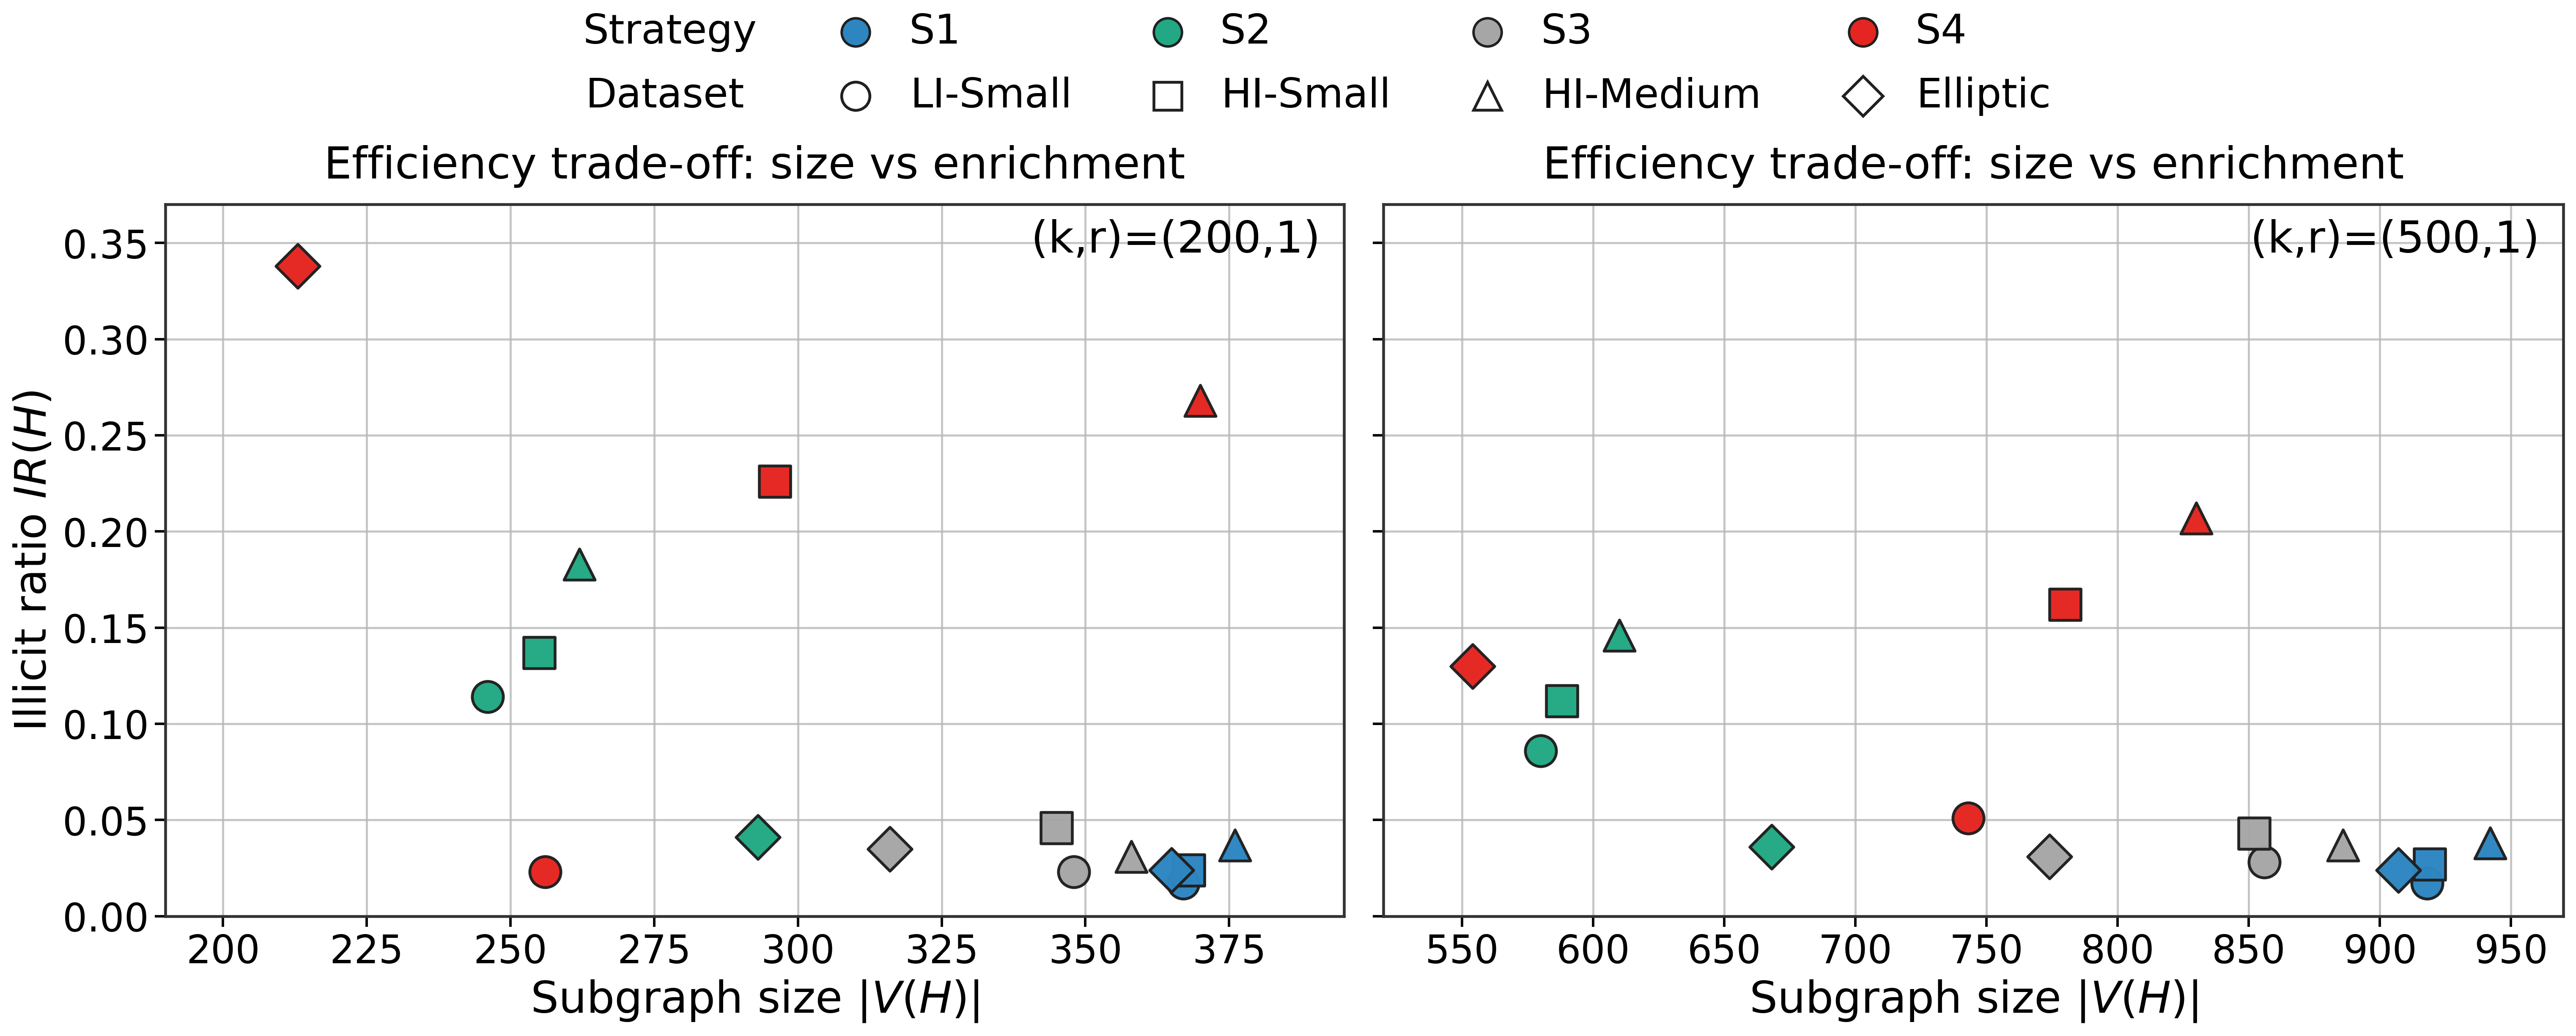

Saved: efficiency_tradeoff_from_table_fixed_legend_colab.png, efficiency_tradeoff_from_table_fixed_legend_colab.pdf, efficiency_tradeoff_from_table_fixed_legend_colab.svg


In [19]:

# Colab-ready script to generate the efficiency trade-off plot
# Run this in Google Colab or as a regular Python script.

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Data taken only from the provided table.
data = {
    (200, 1): {
        "LI-Small":  {"S1": (367, 0.017), "S2": (246, 0.114), "S3": (348, 0.023), "S4": (256, 0.023)},
        "HI-Small":  {"S1": (368, 0.024), "S2": (255, 0.137), "S3": (345, 0.046), "S4": (296, 0.226)},
        "HI-Medium": {"S1": (376, 0.037), "S2": (262, 0.183), "S3": (358, 0.031), "S4": (370, 0.268)},
        "Elliptic":  {"S1": (365, 0.024), "S2": (293, 0.041), "S3": (316, 0.035), "S4": (213, 0.338)},
    },
    (500, 1): {
        "LI-Small":  {"S1": (918, 0.017), "S2": (580, 0.086), "S3": (856, 0.028), "S4": (743, 0.051)},
        "HI-Small":  {"S1": (919, 0.027), "S2": (588, 0.112), "S3": (852, 0.043), "S4": (780, 0.162)},
        "HI-Medium": {"S1": (942, 0.038), "S2": (610, 0.146), "S3": (886, 0.037), "S4": (830, 0.207)},
        "Elliptic":  {"S1": (907, 0.024), "S2": (668, 0.036), "S3": (774, 0.031), "S4": (554, 0.130)},
    },
}

strategy_colors = {
    "S1": "#2E86C1",
    "S2": "#22A884",
    "S3": "#A6A6A6",
    "S4": "#E52521",
}

dataset_markers = {
    "LI-Small": "o",
    "HI-Small": "s",
    "HI-Medium": "^",
    "Elliptic": "D",
}

# Exact canvas size of the reference image: 2047 x 1030 px
fig = plt.figure(figsize=(20.47, 8.00), dpi=300, facecolor="white")

# Axes positions chosen to match the reference layout closely.
ax1 = fig.add_axes([143/2047, (1030-922)/1030, (1072-143)/2047, (922-200)/1030])
ax2 = fig.add_axes([1103/2047, (1030-922)/1030, (2033-1103)/2047, (922-200)/1030], sharey=ax1)
axes = [ax1, ax2]

for ax, (k, r) in zip(axes, [(200, 1), (500, 1)]):
    for dataset, marker in dataset_markers.items():
        for strategy, color in strategy_colors.items():
            x, y = data[(k, r)][dataset][strategy]
            ax.scatter(
                x, y,
                s=310,
                marker=marker,
                facecolor=color,
                edgecolor="#202020",
                linewidth=1.6,
                alpha=0.98,
                zorder=3,
            )

    ax.set_title("Efficiency trade-off: size vs enrichment", fontsize=25, pad=15)
    ax.text(
        0.98, 0.98, f"(k,r)=({k},{r})",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=25,
    )
    ax.grid(True, color="#B8B8B8", linewidth=1.2, alpha=0.8)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_linewidth(1.6)
        spine.set_color("#333333")
    ax.tick_params(axis="both", labelsize=22, width=1.4, length=6)

ax1.set_xlim(190, 395)
ax2.set_xlim(520, 970)
ax1.set_ylim(0.0, 0.37)

ax1.set_xlabel(r"Subgraph size $|V(H)|$", fontsize=25)
ax2.set_xlabel(r"Subgraph size $|V(H)|$", fontsize=25)
ax1.set_ylabel(r"Illicit ratio $IR(H)$", fontsize=25)
ax2.tick_params(labelleft=False)

# Custom top legend to match the original layout.
W, H = 2047, 1030
def fx(x): return x / W
def fy(y): return 1 - y / H

legend_font = 21
marker_size = 16
edgew = 1.4

y1 = fy(25)   # Strategy row
y2 = fy(90)  # Dataset row

fig.text(fx(472), y1, "Strategy", fontsize=legend_font + 2, va="center", ha="left")
fig.text(fx(474), y2, "Dataset",  fontsize=legend_font + 2, va="center", ha="left")

strategy_marker_x = {"S1": 687, "S2": 933, "S3": 1185, "S4": 1481}
strategy_text_x   = {"S1": 729, "S2": 974, "S3": 1227, "S4": 1522}

for s in ["S1", "S2", "S3", "S4"]:
    fig.add_artist(Line2D(
        [fx(strategy_marker_x[s])], [y1],
        marker="o", linestyle="None", markersize=marker_size,
        markerfacecolor=strategy_colors[s], markeredgecolor="#202020",
        markeredgewidth=edgew, transform=fig.transFigure
    ))
    fig.text(fx(strategy_text_x[s]), y1, s, fontsize=legend_font + 2, va="center", ha="left")

dataset_order = ["LI-Small", "HI-Small", "HI-Medium", "Elliptic"]
dataset_marker_x = {"LI-Small": 687, "HI-Small": 933, "HI-Medium": 1185, "Elliptic": 1481}
dataset_text_x   = {"LI-Small": 730, "HI-Small": 975, "HI-Medium": 1228, "Elliptic": 1523}

for d in dataset_order:
    fig.add_artist(Line2D(
        [fx(dataset_marker_x[d])], [y2],
        marker=dataset_markers[d], linestyle="None", markersize=marker_size,
        markerfacecolor="white", markeredgecolor="#202020",
        markeredgewidth=1.6, transform=fig.transFigure
    ))
    fig.text(fx(dataset_text_x[d]), y2, d, fontsize=legend_font + 2, va="center", ha="left")

plt.show()

# Save outputs
base = "efficiency_tradeoff_from_table_fixed_legend_colab"
fig.savefig(base + ".png", dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(base + ".pdf", bbox_inches="tight", facecolor="white")
fig.savefig(base + ".svg", bbox_inches="tight", facecolor="white")
print(f"Saved: {base}.png, {base}.pdf, {base}.svg")


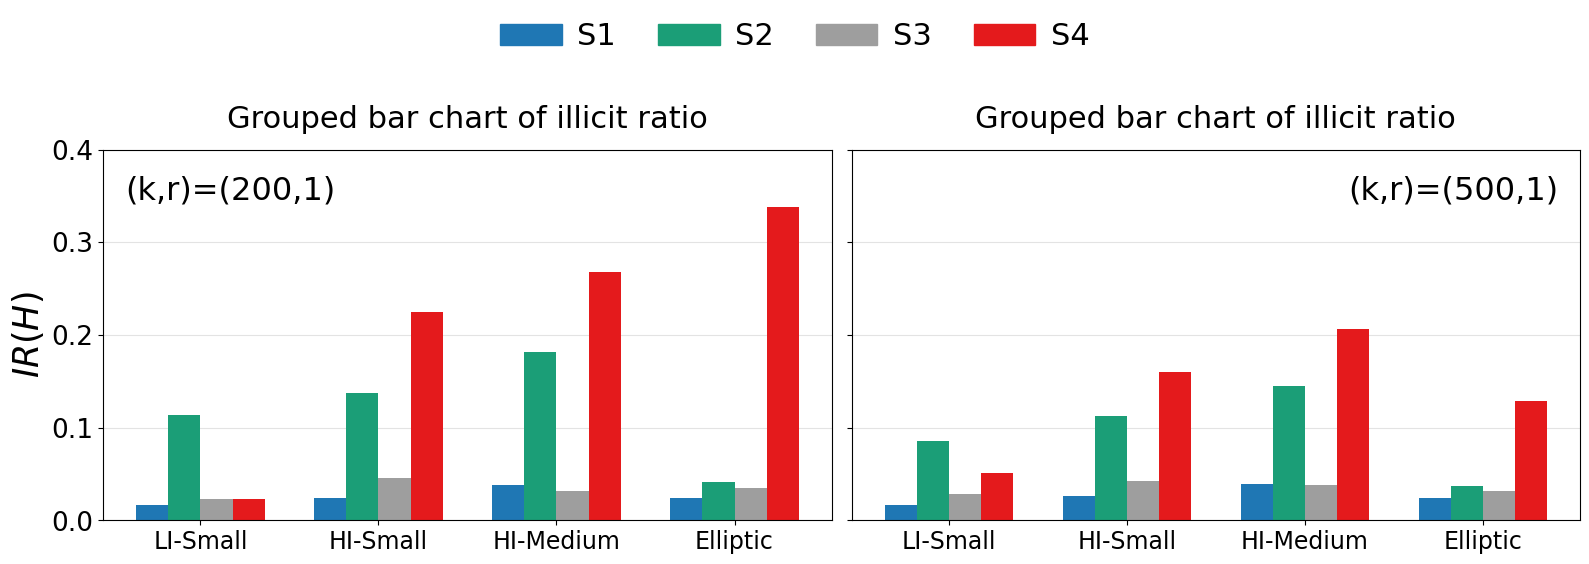

/content/grouped_bar_2panels_updated_LI_small_white_bg.png


In [28]:
import matplotlib.pyplot as plt
import numpy as np

datasets = ["LI-Small", "HI-Small", "HI-Medium", "Elliptic"]

vals_200 = {
    "S1": [0.017, 0.024, 0.038, 0.024],
    "S2": [0.114, 0.137, 0.182, 0.041],
    "S3": [0.023, 0.046, 0.032, 0.035],
    "S4": [0.023, 0.225, 0.268, 0.338],
}

vals_500 = {
    "S1": [0.017, 0.026, 0.039, 0.024],
    "S2": [0.086, 0.112, 0.145, 0.037],
    "S3": [0.028, 0.042, 0.038, 0.032],
    "S4": [0.051, 0.160, 0.206, 0.129],
}

colors = {
    "S1": "#1f77b4",
    "S2": "#1b9e77",
    "S3": "#9e9e9e",
    "S4": "#e41a1c",
}

fig, axes = plt.subplots(1, 2, figsize=(16, 5.578125), sharey=True)
fig.patch.set_facecolor("white")

bar_width = 0.18
x = np.arange(len(datasets))
offsets = [-1.5 * bar_width, -0.5 * bar_width, 0.5 * bar_width, 1.5 * bar_width]

for ax, vals, panel_text in zip(
    axes,
    [vals_200, vals_500],
    ["(k,r)=(200,1)", "(k,r)=(500,1)"]
):
    ax.set_facecolor("white")
    for i, key in enumerate(["S1", "S2", "S3", "S4"]):
        ax.bar(x + offsets[i], vals[key], width=bar_width, color=colors[key], label=key)

    ax.set_xticks(x)
    ax.set_xticklabels(datasets, fontsize=17)
    ax.set_ylim(0, 0.4)
    ax.set_yticks(np.arange(0, 0.41, 0.1))
    ax.tick_params(axis="y", labelsize=19)
    ax.grid(axis="y", alpha=0.35)
    ax.set_axisbelow(True)
    ax.set_title("Grouped bar chart of illicit ratio", fontsize=22, pad=16)
    ax.text(
        0.03 if panel_text == "(k,r)=(200,1)" else 0.97,
        0.93,
        panel_text,
        transform=ax.transAxes,
        fontsize=23,
        ha="left" if panel_text == "(k,r)=(200,1)" else "right",
        va="top",
    )

axes[0].set_ylabel(r"$IR(H)$", fontsize=25)

handles = [plt.Rectangle((0, 0), 1, 1, color=colors[k]) for k in ["S1", "S2", "S3", "S4"]]
labels = ["S1", "S2", "S3", "S4"]
fig.legend(
    handles,
    labels,
    ncol=4,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.03),
    frameon=False,
    fontsize=22,
    handletextpad=0.5,
    columnspacing=1.4,
)

plt.tight_layout(rect=[0, 0, 1, 0.86])

out_path = "/content/grouped_bar_2panels_updated_LI_small_white_bg.png"
plt.savefig(out_path, dpi=300, facecolor="white", bbox_inches="tight")
plt.show()
plt.close(fig)

print(out_path)

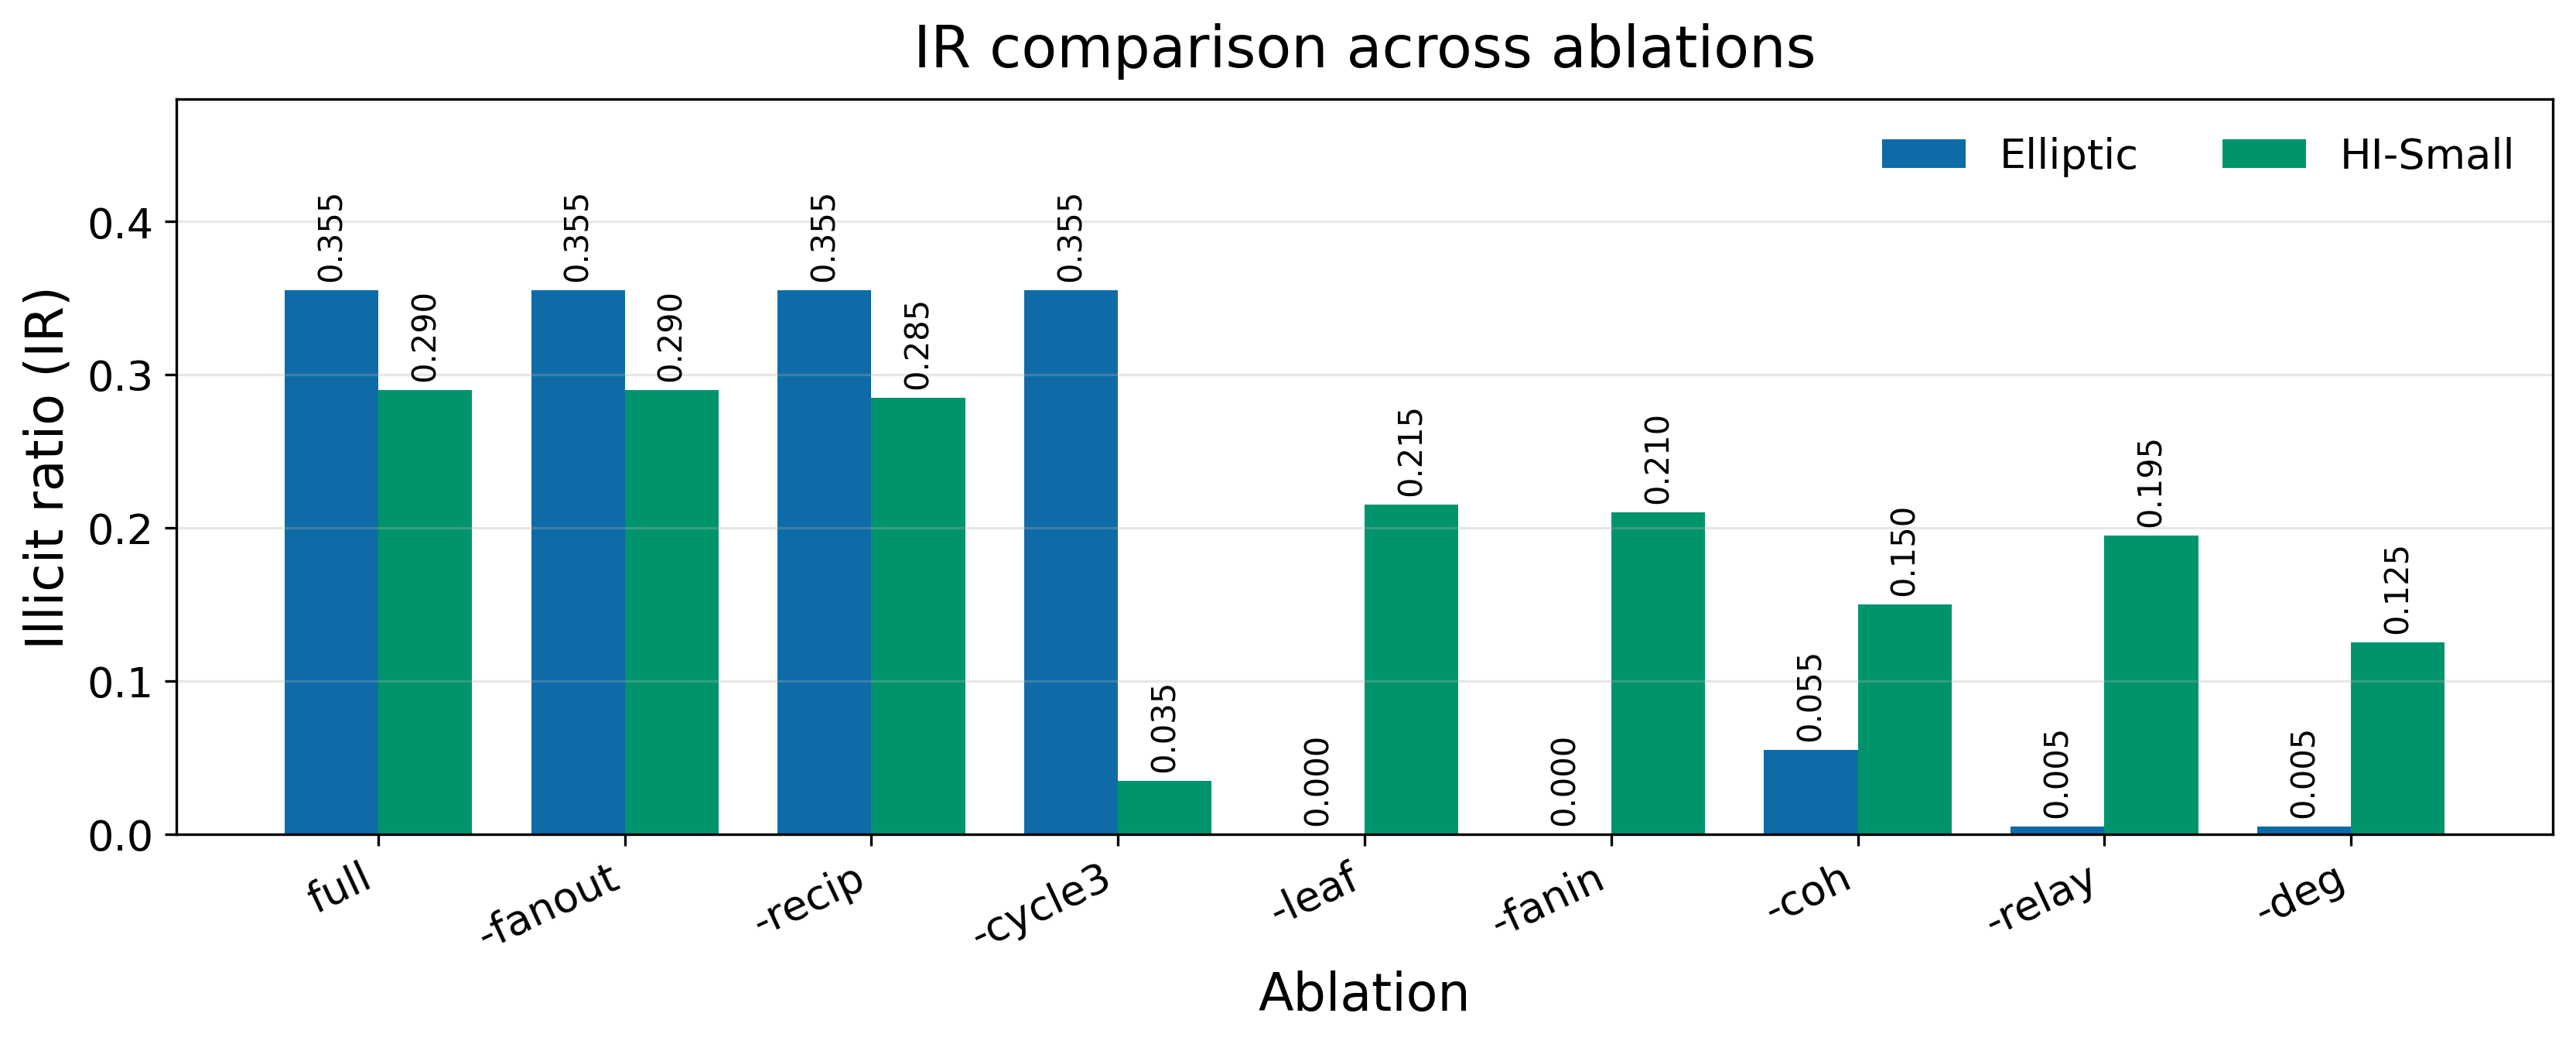

Saved files:
/content/ir_grouped_bar_blue_green_compact_height.png
/content/ir_grouped_bar_blue_green_compact_height.pdf


In [31]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from google.colab import files

# Data
data = pd.DataFrame({
    "Ablation": ["full", "-cycle3", "-recip", "-relay", "-fanin", "-fanout", "-leaf", "-deg", "-coh"],
    "Elliptic": [0.355, 0.355, 0.355, 0.005, 0.000, 0.355, 0.000, 0.005, 0.055],
    "HI-Small": [0.290, 0.035, 0.285, 0.195, 0.210, 0.290, 0.215, 0.125, 0.150],
})

# Keep the same ordering
data["avg_IR"] = data[["Elliptic", "HI-Small"]].mean(axis=1)
data = data.sort_values(["avg_IR", "Elliptic", "HI-Small"], ascending=[False, False, False]).reset_index(drop=True)

# Colors
elliptic_blue = "#0E6BA8"
hismall_green = "#00946D"

x = np.arange(len(data))
w = 0.38

# Reduced figure height to save paper space
fig, ax = plt.subplots(figsize=(11.2, 4.6), dpi=300)

bars1 = ax.bar(x - w/2, data["Elliptic"], width=w, label="Elliptic", color=elliptic_blue)
bars2 = ax.bar(x + w/2, data["HI-Small"], width=w, label="HI-Small", color=hismall_green)

ax.set_xticks(x)
ax.set_xticklabels(data["Ablation"], rotation=25, ha="right", fontsize=13)
ax.set_ylabel("Illicit ratio (IR)", fontsize=16)
ax.set_xlabel("Ablation", fontsize=16)
ax.set_title("IR comparison across ablations", fontsize=18, pad=10)
ax.legend(frameon=False, fontsize=13, ncol=2, loc="upper right")
ax.grid(True, axis="y", alpha=0.3)
ax.set_ylim(0, 0.48)
ax.tick_params(axis="y", labelsize=13)

for bars in (bars1, bars2):
    for b in bars:
        h = b.get_height()
        ax.text(
            b.get_x() + b.get_width() / 2,
            h + 0.006,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontsize=10,
            rotation=90,
        )

fig.tight_layout()

# Save in Colab working directory
out_dir = Path("/content")
png_path = out_dir / "ir_grouped_bar_blue_green_compact_height.png"
pdf_path = out_dir / "ir_grouped_bar_blue_green_compact_height.pdf"

fig.savefig(png_path, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")

plt.show()

print("Saved files:")
print(png_path)
print(pdf_path)

# Optional: download automatically
# files.download(str(png_path))
# files.download(str(pdf_path))

In [ ]:
##########################################################################################
##########################################################################################
# Sensitivity plot

In [54]:
from google.colab import files
uploaded = files.upload()

Saving s4_sensitivity_elliptic_k200_r1_induced_full.csv to s4_sensitivity_elliptic_k200_r1_induced_full.csv
Saving s4_sensitivity_hi-medium_k200_r1_induced_full.csv to s4_sensitivity_hi-medium_k200_r1_induced_full.csv
Saving s4_sensitivity_hi-small_k200_r1_induced_full.csv to s4_sensitivity_hi-small_k200_r1_induced_full.csv
Saving s4_sensitivity_li-small_k200_r1_induced_full.csv to s4_sensitivity_li-small_k200_r1_induced_full.csv


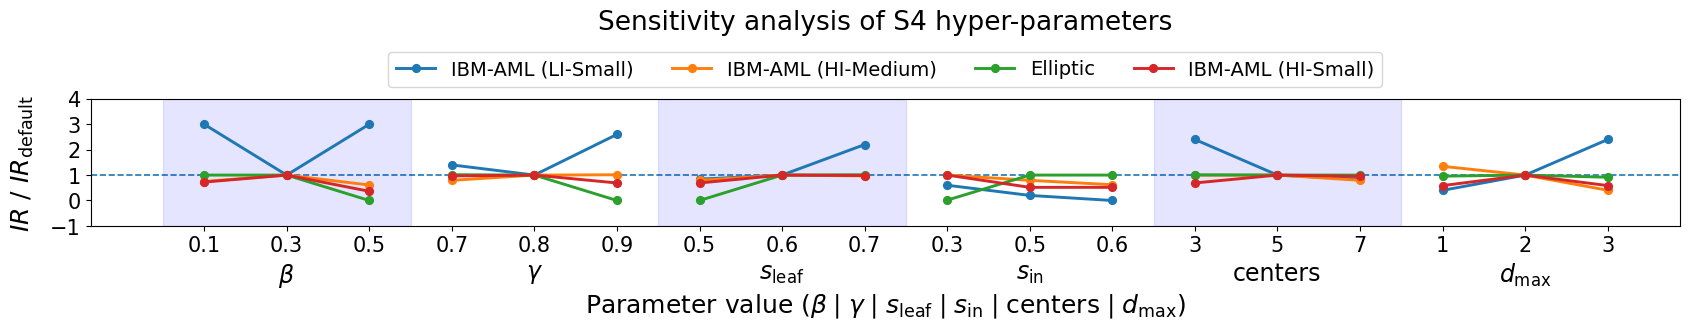

Saved: /content/s4_sensitivity_single_plot_final.png
Saved: /content/s4_sensitivity_single_plot_final.pdf


In [96]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

base = Path("/content")   # or your Drive path

paths = {
    "IBM-AML (LI-Small)": base / "s4_sensitivity_li-small_k200_r1_induced_full.csv",
    "IBM-AML (HI-Medium)": base / "s4_sensitivity_hi-medium_k200_r1_induced_full.csv",
    "Elliptic": base / "s4_sensitivity_elliptic_k200_r1_induced_full.csv",
    "IBM-AML (HI-Small)": base / "s4_sensitivity_hi-small_k200_r1_induced_full.csv",

}

dfs = {name: pd.read_csv(path) for name, path in paths.items()}

all_factors = []
factor_values = {}
for df in dfs.values():
    for factor in df["factor"].dropna().unique():
        if factor == "baseline":
            continue
        if factor not in all_factors:
            all_factors.append(factor)
        vals = pd.to_numeric(df.loc[df["factor"] == factor, "value"], errors="coerce").dropna().tolist()
        factor_values.setdefault(factor, set()).update(vals)

factor_values = {f: sorted(factor_values[f]) for f in all_factors}

# Original positions used for ticks and separators
order = [(factor, value) for factor in all_factors for value in factor_values[factor]]
x = np.arange(len(order))
x_labels = [str(int(v)) if float(v).is_integer() else str(v) for _, v in order]

plt.figure(figsize=(17, 3.5))

# Precompute group ranges
group_ranges = []
cursor = 0
for factor in all_factors:
    n = len(factor_values[factor])
    group_ranges.append((factor, cursor, cursor + n))
    cursor += n

for dataset_name, df in dfs.items():
    baseline_ir = float(df.loc[df["factor"] == "baseline", "IR"].iloc[0])
    df2 = df.copy()
    df2["value_num"] = pd.to_numeric(df2["value"], errors="coerce")

    x_plot = []
    y_plot = []

    for factor, start, end in group_ranges:
        vals = factor_values[factor]

        for i, value in enumerate(vals):
            xpos = start + i
            row = df2[(df2["factor"] == factor) & (df2["value_num"] == value)]
            if row.empty or baseline_ir == 0:
                yval = np.nan
            else:
                yval = float(row["IR"].iloc[0]) / baseline_ir

            x_plot.append(xpos)
            y_plot.append(yval)

        # Add a gap after each hyper-parameter group except the last one
        if factor != all_factors[-1]:
            x_plot.append(np.nan)
            y_plot.append(np.nan)

    plt.plot(x_plot, y_plot, marker="o", linewidth=2.1, markersize=5.6, label=dataset_name, zorder=3)

plt.axhline(1.0, linestyle="--", linewidth=1.2, zorder=0)

separator_positions = []
group_centers = []
group_names = []
cursor = 0
for factor in all_factors:
    n = len(factor_values[factor])
    group_centers.append(cursor + (n - 1) / 2)
    group_names.append(factor)
    cursor += n
    separator_positions.append(cursor - 0.5)

#for pos in separator_positions[:-1]:
    #plt.axvline(pos, linestyle=":", linewidth=1.1, zorder=1)

ax = plt.gca()

cursor = 0
for i, factor in enumerate(all_factors):
    n = len(factor_values[factor])
    left = cursor - 0.5
    right = cursor + n - 0.5

    if i % 2 == 0:
        ax.axvspan(left, right, alpha=0.1, color="blue")

    cursor += n

plt.xticks(x, x_labels, fontsize=15)
plt.yticks(np.arange(-1, 4.1, 1.0), fontsize=15)
#plt.yticks(fontsize=13)
#plt.ylabel(r"Relative illicit ratio, $IR / IR_{\mathrm{default}}$", fontsize=16, labelpad=12)
plt.ylabel(r"$IR \ / \ IR_{\mathrm{default}}$", fontsize=18, labelpad=10)
plt.xlabel(
    r"Parameter value ($\beta \mid \gamma \mid s_{\mathrm{leaf}} \mid s_{\mathrm{in}} \mid \mathrm{centers} \mid d_{\max}$)",
    fontsize=18,
    labelpad=26,
)
plt.title("Sensitivity analysis of S4 hyper-parameters", fontsize=19, pad=50)

ax = plt.gca()
display_names = {
    "beta": r"$\beta$",
    "gamma": r"$\gamma$",
    "s_leaf": r"$s_{\mathrm{leaf}}$",
    "s_in": r"$s_{\mathrm{in}}$",
    "centers": "centers",
    "d_max": r"$d_{\max}$",
    "tau": r"$\tau$",
}
for xc, name in zip(group_centers, group_names):
    ax.text(
        xc,
        -0.28,
        display_names.get(name, name),
        ha="center",
        va="top",
        fontsize=17,
        transform=ax.get_xaxis_transform(),
    )
plt.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), frameon=True, ncol=4, fontsize=14)
#plt.legend(frameon=True, ncol=4, fontsize=11)
plt.tight_layout()

png_path = base / "s4_sensitivity_single_plot_final.png"
pdf_path = base / "s4_sensitivity_single_plot_final.pdf"
plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()
plt.close()

print(f"Saved: {png_path}")
print(f"Saved: {pdf_path}")